In [10]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

In [11]:
# Step 1: Check if the file exists and read the first 5 lines
file_path = "logfiles.log" 

try:
    with open(file_path, "r") as file:
        print(f"--- Successfully opened {file_path} ---")
        for i in range(5):
            print(file.readline().strip())
except FileNotFoundError:
    print("Error: The file was not found. Make sure it is in the same folder as this notebook!")

--- Successfully opened logfiles.log ---
76.103.128.42 - - [07/Apr/2017:00:00:00 +0530] "PUT /usr/admin HTTP/1.0" 404 4864 "http://www.parker-miller.org/tag/list/list/privacy/" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.4380.0 Safari/537.36 Edg/89.0.759.0" 4927
244.126.247.177 - - [07/Apr/2017:00:00:00 +0530] "DELETE /usr/admin/developer HTTP/1.0" 500 5153 "http://www.parker-miller.org/tag/list/list/privacy/" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/537.75.14 (KHTML, like Gecko) Version/7.0.3 Safari/7046A194A" 731
187.78.185.113 - - [07/Apr/2017:00:00:00 +0530] "POST /usr/login HTTP/1.0" 200 4810 "http://www.parker-miller.org/tag/list/list/privacy/" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/537.75.14 (KHTML, like Gecko) Version/7.0.3 Safari/7046A194A" 2971
39.6.86.240 - - [07/Apr/2017:00:00:00 +0530] "POST /usr/admin HTTP/1.0" 304 4867 "-" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/

In [12]:
# 1. Path to your log file
log_file = "logfiles.log"  

# 2. The Regex Pattern
# This pattern extracts: [IP] [Timestamp] [Request Type] [Status Code]
log_regex = r'(\d+\.\d+\.\d+\.\d+) - - \[(.*?)\] "(.*?)" (\d+) (\d+)'

data = []

with open(log_file, "r") as f:
    for line in f:
        match = re.search(log_regex, line)
        if match:
            ip, timestamp, request, status, size = match.groups()
            
            # For your project, focus on "Error" codes (anything starting with 4 or 5)
            if status.startswith(('4', '5')):
                data.append({
                    "Time": timestamp,
                    "Status": status,
                    "Request": request
                })

# 3. Create the DataFrame
df = pd.DataFrame(data)

# 4. Convert timestamp to a readable format
# Apache logs use format: 10/Mar/2026:10:05:22 +0000
df['Time'] = pd.to_datetime(df['Time'], format='%d/%b/%Y:%H:%M:%S %z', errors='coerce')

print(f"Parsed {len(df)} noisy lines and found {len(data)} critical errors!")
df.head()

Parsed 491346 noisy lines and found 491346 critical errors!


,Time,Status,Request
0,2017-04-07 00:00:00+05:30,404,PUT /usr/admin HTTP/1.0
1,2017-04-07 00:00:00+05:30,500,DELETE /usr/admin/developer HTTP/1.0
2,2017-04-07 00:00:00+05:30,500,POST /usr HTTP/1.0
3,2017-04-07 00:00:00+05:30,404,POST /usr HTTP/1.0
4,2017-04-07 00:00:00+05:30,404,DELETE /usr/register HTTP/1.0


C:\Users\MUNTHAS\AppData\Local\Temp\ipykernel_13904\2357298753.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  error_trend = df.set_index('Time').resample('H').size()
C:\Users\MUNTHAS\AppData\Local\Temp\ipykernel_13904\2357298753.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_endpoints.values, y=top_endpoints.index, ax=axes[1, 0], palette='magma')


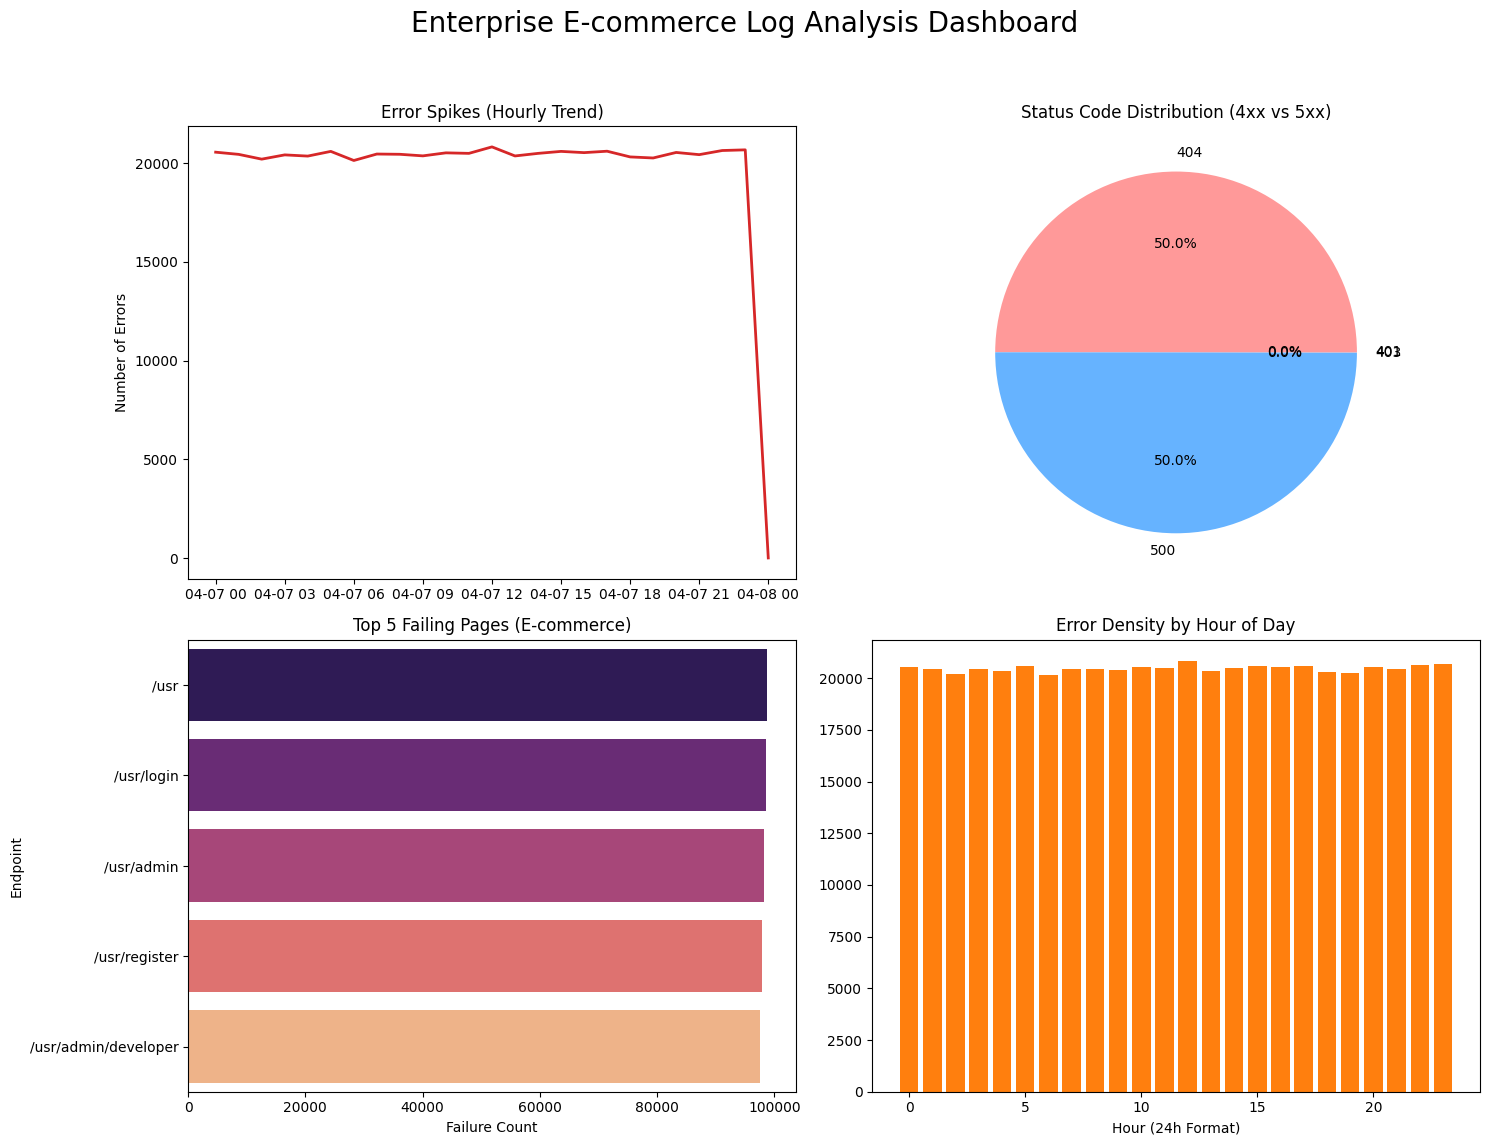

In [13]:
# Setting style for the graphs
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Enterprise E-commerce Log Analysis Dashboard', fontsize=20)

# --- CHART 1: Errors Over Time (Line Chart) ---
# Resampling by Hour to see "Spikes"
error_trend = df.set_index('Time').resample('H').size()
axes[0, 0].plot(error_trend.index, error_trend.values, color='tab:red', linewidth=2)
axes[0, 0].set_title('Error Spikes (Hourly Trend)')
axes[0, 0].set_ylabel('Number of Errors')

# --- CHART 2: Error Distribution (Pie Chart) ---
status_dist = df['Status'].value_counts()
axes[0, 1].pie(status_dist, labels=status_dist.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[0, 1].set_title('Status Code Distribution (4xx vs 5xx)')

# --- CHART 3: Top Failing Endpoints (Horizontal Bar) ---
# Cleaning the "Request" string to show just the URL
df['Endpoint'] = df['Request'].str.split().str[1]
top_endpoints = df['Endpoint'].value_counts().head(5)
sns.barplot(x=top_endpoints.values, y=top_endpoints.index, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Top 5 Failing Pages (E-commerce)')
axes[1, 0].set_xlabel('Failure Count')

# --- CHART 4: Heatmap of Error Density ---
# This shows which hour of the day is most "dangerous"
df['Hour'] = df['Time'].dt.hour
hour_counts = df['Hour'].value_counts().sort_index()
axes[1, 1].bar(hour_counts.index, hour_counts.values, color='tab:orange')
axes[1, 1].set_title('Error Density by Hour of Day')
axes[1, 1].set_xlabel('Hour (24h Format)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()